In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

with zipfile.ZipFile('/content/drive/Shareddrives/depth_estimators/waymo_open/output/images.zip', 'r') as z:
    z.extractall('/content/images/')

In [3]:
import cv2, glob

images = sorted(glob.glob("/content/images/images/*.png"))
assert len(images) > 0, "No images found! Check the zip extraction path."

img = cv2.imread(images[0])
h, w = img.shape[:2]

print(f"Found {len(images)} frames at {w}x{h}")
print(f"Input dir: /content/images/images/")

Found 199 frames at 1920x1280
Input dir: /content/images/images/


In [4]:
!git clone https://github.com/DepthAnything/Video-Depth-Anything.git
%cd Video-Depth-Anything
!pip install -r requirements.txt

Cloning into 'Video-Depth-Anything'...
remote: Enumerating objects: 356, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 356 (delta 143), reused 81 (delta 81), pack-reused 177 (from 1)
Receiving objects: 100% (356/356), 7.60 MiB | 14.38 MiB/s, done.
Resolving deltas: 100% (197/197), done.
/content/Video-Depth-Anything
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is li

In [5]:
!pip install timm einops opencv-python-headless matplotlib pillow huggingface_hub -q
print('Install complete.')

Install complete.


In [6]:
import os
os.chdir('/content/Video-Depth-Anything')

from huggingface_hub import hf_hub_download

os.makedirs('checkpoints', exist_ok=True)

ckpt_path = hf_hub_download(
    repo_id='depth-anything/Video-Depth-Anything-Base',
    filename='video_depth_anything_vitb.pth',
    local_dir='checkpoints'
)

print(f'Weights downloaded to: {ckpt_path}')
!ls -lh checkpoints/

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


video_depth_anything_vitb.pth:   0%|          | 0.00/458M [00:00<?, ?B/s]

Weights downloaded to: checkpoints/video_depth_anything_vitb.pth
total 438M
-rw-r--r-- 1 root root 438M Mar  9 03:53 video_depth_anything_vitb.pth


In [7]:
import cv2, glob

FRAMES_DIR = '/content/images/images'
VIDEO_PATH = '/content/waymo_frames.mp4'
FPS = 10

frames = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
sample = cv2.imread(frames[0])
H, W = sample.shape[:2]

writer = cv2.VideoWriter(
    VIDEO_PATH,
    cv2.VideoWriter_fourcc(*'mp4v'),
    FPS,
    (W, H)
)

for f in frames:
    writer.write(cv2.imread(f))
writer.release()

print(f'Video written: {VIDEO_PATH}')
print(f'{len(frames)} frames at {W}x{H} @ {FPS}fps')
!ls -lh /content/waymo_frames.mp4

Video written: /content/waymo_frames.mp4
199 frames at 1920x1280 @ 10fps
-rw-r--r-- 1 root root 22M Mar  9 03:54 /content/waymo_frames.mp4


In [8]:
with open('/content/Video-Depth-Anything/run.py', 'r') as f:
    content = f.read()

content = content.replace(
    'save_video(frames, processed_video_path, fps=fps)\n    save_video(depths, depth_vis_path, fps=fps, is_depths=True, grayscale=args.grayscale)',
    '# save_video(frames, processed_video_path, fps=fps)\n    # save_video(depths, depth_vis_path, fps=fps, is_depths=True, grayscale=args.grayscale)'
)

with open('/content/Video-Depth-Anything/run.py', 'w') as f:
    f.write(content)

# Verify the patch
!grep -n 'save_video' /content/Video-Depth-Anything/run.py

20:from utils.dc_utils import read_video_frames, save_video
64:    # save_video(frames, processed_video_path, fps=fps)
65:    # save_video(depths, depth_vis_path, fps=fps, is_depths=True, grayscale=args.grayscale)


In [9]:
import os
os.chdir('/content/Video-Depth-Anything')

!python3 run.py \
    --input_video /content/waymo_frames.mp4 \
    --output_dir /content/depth_output \
    --encoder vitb \
    --input_size 308 \
    --max_res 512 \
    --save_npz

print('Inference complete.')
!ls -lh /content/depth_output/

xFormers not available
xFormers not available
xFormers not available
xFormers not available
100% 10/10 [00:11<00:00,  1.15s/it]
Inference complete.
total 104M
-rw-r--r-- 1 root root 104M Mar  9 03:54 waymo_frames_depths.npz


In [10]:
import numpy as np
import cv2
import glob
from pathlib import Path

# ── Config ─────────────────────────────────────────────────────────────────
TARGET_H   = 192
TARGET_W   = 640
FRAMES_DIR = '/content/images/images'
DEPTH_OUT  = Path('/content/vda2_output/depth_arrays')
STACK_FILE = Path('/content/vda2_output/pred_depth_stack.npy')
DEPTH_OUT.mkdir(parents=True, exist_ok=True)

# ── Load raw VDA2 output ────────────────────────────────────────────────────
raw = np.load('/content/depth_output/waymo_frames_depths.npz')['depths']
print(f'Raw VDA2 output shape: {raw.shape}')  # expect (199, H, W)

frame_files = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
assert raw.shape[0] == len(frame_files), \
    f'Mismatch: {raw.shape[0]} depth frames vs {len(frame_files)} PNGs'

# ── Resize each frame to (192, 640) and save ────────────────────────────────
depth_frames = []

for i in range(raw.shape[0]):
    stem  = Path(frame_files[i]).stem
    depth = raw[i].astype(np.float32)

    depth_resized = cv2.resize(depth, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)

    out_path = DEPTH_OUT / f'{stem}_depth.npy'
    np.save(out_path, depth_resized)
    depth_frames.append(depth_resized)

    if i % 20 == 0:
        print(f'  [{i+1}/{raw.shape[0]}] {stem}  shape={depth_resized.shape}  '
              f'range=[{depth_resized.min():.2f}, {depth_resized.max():.2f}]')

# ── Stack and save ──────────────────────────────────────────────────────────
depth_stack = np.stack(depth_frames, axis=0).astype(np.float32)
np.save(STACK_FILE, depth_stack)

print(f'\nDone!')
print(f'Stack shape : {depth_stack.shape}  <- should be (199, 192, 640)')
print(f'Depth arrays: {DEPTH_OUT}')
print(f'Stack file  : {STACK_FILE}')

Raw VDA2 output shape: (199, 341, 512)
  [1/199] frame_00000  shape=(192, 640)  range=[0.00, 34.40]
  [21/199] frame_00020  shape=(192, 640)  range=[0.00, 34.41]
  [41/199] frame_00040  shape=(192, 640)  range=[0.00, 34.27]
  [61/199] frame_00060  shape=(192, 640)  range=[0.00, 31.88]
  [81/199] frame_00080  shape=(192, 640)  range=[0.00, 32.89]
  [101/199] frame_00100  shape=(192, 640)  range=[0.00, 34.65]
  [121/199] frame_00120  shape=(192, 640)  range=[0.00, 33.96]
  [141/199] frame_00140  shape=(192, 640)  range=[0.00, 34.66]
  [161/199] frame_00160  shape=(192, 640)  range=[0.00, 41.76]
  [181/199] frame_00180  shape=(192, 640)  range=[0.00, 32.64]

Done!
Stack shape : (199, 192, 640)  <- should be (199, 192, 640)
Depth arrays: /content/vda2_output/depth_arrays
Stack file  : /content/vda2_output/pred_depth_stack.npy


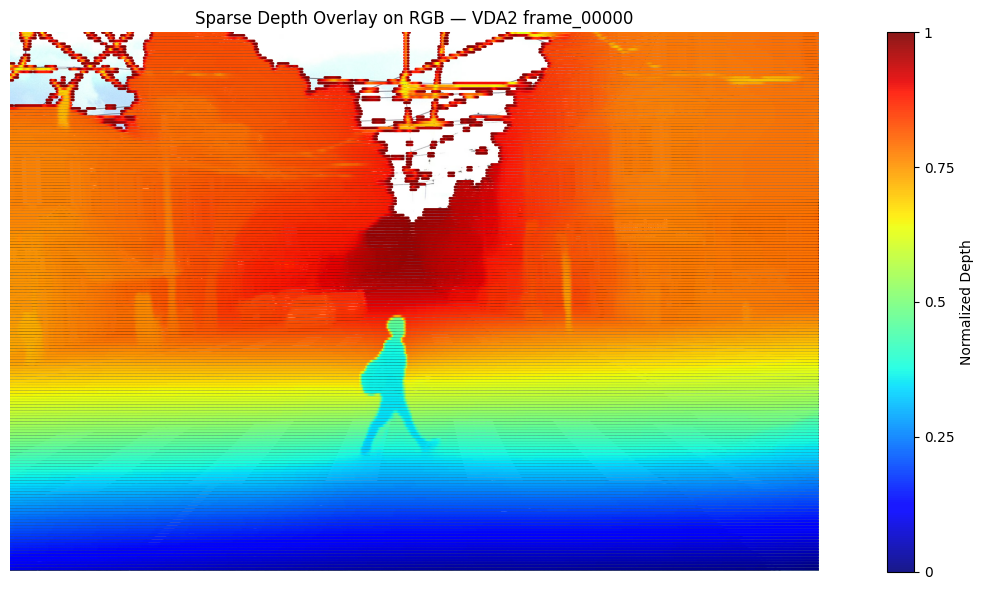

Depth shape : (192, 640)
Valid pixels: 114790
Density     : 0.9341634114583334
Min depth   : 0.0000
Max depth   : 1.0000
Mean depth  : 0.6237


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from PIL import Image

# ... (loading logic stays the same) ...
depth = np.load('/content/vda2_output/depth_arrays/frame_00000_depth.npy').astype(np.float32)
rgb   = np.array(Image.open(sorted(glob.glob('/content/images/images/*.png'))[0]))

H_img, W_img = rgb.shape[:2]
H_d, W_d     = depth.shape

valid = np.isfinite(depth) & (depth > 0)
ys, xs = np.where(valid)
vals   = depth[ys, xs]

xs_img = xs * (W_img / W_d)
ys_img = ys * (H_img / H_d)

# 1. Normalize to 0-1
vmin, vmax = vals.min(), vals.max()
vals_norm = (vals - vmin) / (vmax - vmin)

# 2. THE HARD-CODE FLIP:
# If your background is blue but should be red, we subtract from 1.
# This ensures 1.0 (Far) = Red and 0.0 (Near) = Blue.
vals_final = 1 - vals_norm

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(rgb)

# 3. Use 'jet' (NOT 'jet_r') so the sidebar shows Blue at 0 and Red at 1
sc = ax.scatter(xs_img, ys_img, c=vals_final, cmap='jet', s=1, alpha=0.9, vmin=0, vmax=1)

# 4. SIDEBAR: Fixed at 0-1 with Blue at bottom and Red at top
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Normalized Depth')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0', '0.25', '0.5', '0.75', '1'])

ax.set_title('Sparse Depth Overlay on RGB — VDA2 frame_00000')
ax.axis('off')
plt.tight_layout()
plt.show()

# 5. PRINT: Shows the 0-1 range
print('Depth shape :', depth.shape)
print('Valid pixels:', valid.sum())
print('Density     :', f'{valid.sum()/depth.size}')
print('Min depth   :', f'{vals_final.min():.4f}')
print('Max depth   :', f'{vals_final.max():.4f}')
print('Mean depth  :', f'{vals_final.mean():.4f}')

In [68]:
import numpy as np
import glob
import os

# 1. Path to the individual frames you just inferenced
input_path = '/content/vda2_output/depth_arrays/*.npy'
files = sorted(glob.glob(input_path))

# 2. Destination in the Shared Drive
shared_drive_path = '/content/drive/Shared drives/depth_estimators/video_depth_anything_v2.npy'

if len(files) == 199:
    print(f"Found all 199 frames. Packing into one file...")

    # Load and stack all frames into a 3D array: (Frames, Height, Width)
    all_frames = [np.load(f) for f in files]
    master_array = np.stack(all_frames, axis=0).astype(np.float32)

    # Save directly to the Shared Drive location
    np.save(shared_drive_path, master_array)

    print(f"SUCCESS! File saved to Shared Drive.")
    print(f"Path: {shared_drive_path}")
    print(f"Final shape: {master_array.shape}")
else:
    print(f"Error: Found {len(files)} frames, but expected 199. Check your inference output folder.")

Found all 199 frames. Packing into one file...
✅ SUCCESS! File saved to Shared Drive.
Path: /content/drive/Shared drives/depth_estimators/video_depth_anything_v2.npy
Final shape: (199, 192, 640)
